In [118]:
library(tidyverse) # dplyr and ggplot2; CRAN
library(Seurat) # Seurat toolkit; CRAN
library(hdf5r) # for data import; CRAN
library(patchwork) # for plotting; CRAN 
library(presto) # for differential expression; Github
library(glmGamPoi) # for sctransform; Bioconductor
library(ggplot2) # for visualization; installed with tidyverse
library(dplyr) #just to make sure it was called; installed with tidyverse


library(SingleR) # for cell type annotation; Bioconductor
library(celldex) # for cell type annotation reference; Bioconductor
library(MAST) # for differential expression; Bioconductor
library(HGNChelper)
library(openxlsx)

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.



In [44]:
# Read in entire file
tirosh <- read.delim("./GSE72056_melanoma_single_cell_revised_v2.txt", header = T, stringsAsFactors = F)


In [46]:
# Pull only gene information
tirosh_genes <- tirosh[-1:-3,]

# Duplicate gene names so make names unique (up to you how you want to deal with this part)
gene_list <- tirosh_genes %>% 
  pull("Cell") %>% 
  make.unique(sep = ".")

# Add back unique rownames
rownames(tirosh_genes) <- gene_list

# Remove Column of gene names
tirosh_genes <- tirosh_genes[, -1]

as.matrix(tirosh_genes)
head(tirosh_genes)


,Cy72_CD45_H02_S758_comb,CY58_1_CD45_B02_S974_comb,Cy71_CD45_D08_S524_comb,Cy81_FNA_CD45_B01_S301_comb,Cy80_II_CD45_B07_S883_comb,Cy81_Bulk_CD45_B10_S118_comb,Cy72_CD45_D09_S717_comb,Cy74_CD45_A03_S387_comb,Cy71_CD45_B05_S497_comb,Cy80_II_CD45_C09_S897_comb,⋯,CY75_1_CD45_CD8_7__S265_comb,CY75_1_CD45_CD8_3__S127_comb,CY75_1_CD45_CD8_1__S61_comb,CY75_1_CD45_CD8_1__S12_comb,CY75_1_CD45_CD8_1__S25_comb,CY75_1_CD45_CD8_7__S223_comb,CY75_1_CD45_CD8_1__S65_comb,CY75_1_CD45_CD8_1__S93_comb,CY75_1_CD45_CD8_1__S76_comb,CY75_1_CD45_CD8_7__S274_comb
C9orf152,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,⋯,0.00000,0.00000,0.000000,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.00000
RPS11,9.21720,8.37450,9.31300,7.88760,8.3291,7.83360,8.3737,8.13380,8.4373,7.59680,⋯,0.00000,7.86390,5.850500,0.626390,6.27340000,5.48890,4.92620,7.09580,3.997000,3.98970
ELMO2,0.00000,0.00000,2.12630,0.00000,0.0000,0.77400,0.0000,0.00000,0.0000,0.38294,⋯,0.00000,0.00000,3.157200,4.793200,0.00000000,0.00000,5.52960,0.00000,0.000000,0.00000
CREB3L1,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,⋯,0.00000,0.00000,0.000000,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.00000
PNMA1,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,2.51420,⋯,0.00000,0.00000,0.000000,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.00000
MMP2,0.00000,0.00000,0.73812,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,2.86970,⋯,0.00000,0.00000,0.000000,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.00000
TMEM216,0.00000,0.00000,0.00000,0.00000,3.7949,0.00000,0.0000,0.00000,0.0000,0.00000,⋯,0.00000,0.00000,3.682900,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.29007
TRAF3IP2-AS1,2.85140,2.09830,0.61730,0.96495,1.4735,3.15800,1.3080,1.38020,0.0000,1.12630,⋯,3.75450,1.74710,1.787700,1.384000,1.34090000,2.40520,1.69880,1.55890,0.471250,1.67460
LRRC37A5P,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,⋯,0.00000,0.00000,0.000000,0.000000,0.00000000,0.00000,0.00000,0.00000,0.000000,0.00000
LOC653712,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,⋯,0.54798,0.00000,0.000000,0.000000,0.00072099,0.00000,0.00000,0.00000,0.000000,0.00000


,Cy72_CD45_H02_S758_comb,CY58_1_CD45_B02_S974_comb,Cy71_CD45_D08_S524_comb,Cy81_FNA_CD45_B01_S301_comb,Cy80_II_CD45_B07_S883_comb,Cy81_Bulk_CD45_B10_S118_comb,Cy72_CD45_D09_S717_comb,Cy74_CD45_A03_S387_comb,Cy71_CD45_B05_S497_comb,Cy80_II_CD45_C09_S897_comb,⋯,CY75_1_CD45_CD8_7__S265_comb,CY75_1_CD45_CD8_3__S127_comb,CY75_1_CD45_CD8_1__S61_comb,CY75_1_CD45_CD8_1__S12_comb,CY75_1_CD45_CD8_1__S25_comb,CY75_1_CD45_CD8_7__S223_comb,CY75_1_CD45_CD8_1__S65_comb,CY75_1_CD45_CD8_1__S93_comb,CY75_1_CD45_CD8_1__S76_comb,CY75_1_CD45_CD8_7__S274_comb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
C9orf152,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,⋯,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
RPS11,9.2172,8.3745,9.31300,7.8876,8.3291,7.8336,8.3737,8.1338,8.4373,7.59680,⋯,0,7.8639,5.8505,0.62639,6.2734,5.4889,4.9262,7.0958,3.997,3.9897
ELMO2,0.0000,0.0000,2.12630,0.0000,0.0000,0.7740,0.0000,0.0000,0.0000,0.38294,⋯,0,0.0000,3.1572,4.79320,0.0000,0.0000,5.5296,0.0000,0.000,0.0000
CREB3L1,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,⋯,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
PNMA1,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.51420,⋯,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
MMP2,0.0000,0.0000,0.73812,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.86970,⋯,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000


In [58]:
# Pull meta data columns from original data
tirosh_meta <- tirosh[1:3,]

# Make rownames equal to column 1 values
rownames(tirosh_meta) <- tirosh_meta[, 1]

# Remove column 1
tirosh_meta <- tirosh_meta[, -1]

# Transpose meta data as Seurat expects meta data to have cell names as rows and meta data values as columns
tirosh_meta_transpose <- data.frame(t(tirosh_meta))

colnames(tirosh_meta_transpose) <- c("tumor_cells",
                                    "malignant",
                                    "cell_type")

In [59]:
tirosh_meta_transpose$malignant <- dplyr::recode(tirosh_meta_transpose$malignant,
                                `0` = "unresolved",
                                `1` = "non_malignant",
                                `2` = "malignant")

head(tirosh_meta_transpose)

,tumor_cells,malignant,cell_type
,<dbl>,<chr>,<dbl>
Cy72_CD45_H02_S758_comb,72,non_malignant,2
CY58_1_CD45_B02_S974_comb,58,non_malignant,1
Cy71_CD45_D08_S524_comb,71,malignant,0
Cy81_FNA_CD45_B01_S301_comb,81,malignant,0
Cy80_II_CD45_B07_S883_comb,80,malignant,0
Cy81_Bulk_CD45_B10_S118_comb,81,malignant,0


In [60]:
tirosh_meta_transpose$cell_type <- dplyr::recode(tirosh_meta_transpose$cell_type,
                                `1` = "T_cell",
                                `2` = "B_cell",
                                `3` = "Macrophage",
                                `4` = "Endothelial",
                                `5` = "CAF",
                                `6` = "NK_cell",
                                `0` = "unknown")

In [61]:
tirosh_meta_transpose$tumor_cells <- paste0("Mel_", tirosh_meta_transpose$tumor_cells)

In [62]:
tirosh_meta_transpose$malignant <- as.factor(tirosh_meta_transpose$malignant)
tirosh_meta_transpose$cell_type <- as.factor(tirosh_meta_transpose $cell_type)
tirosh_meta_transpose$tumor_cells <- as.factor(tirosh_meta_transpose$tumor_cells)

In [63]:

# Create Seurat Object
adp <- CreateSeuratObject(counts = tirosh_genes, meta.data = tirosh_meta_transpose)
View(adp@meta.data)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


,orig.ident,nCount_RNA,nFeature_RNA,tumor_cells,malignant,cell_type
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>
Cy72_CD45_H02_S758_comb,SeuratProject,7143.363,3365,Mel_72,non_malignant,B_cell
CY58_1_CD45_B02_S974_comb,SeuratProject,8915.833,3637,Mel_58,non_malignant,T_cell
Cy71_CD45_D08_S524_comb,SeuratProject,12578.256,4660,Mel_71,malignant,unknown
Cy81_FNA_CD45_B01_S301_comb,SeuratProject,16763.658,6387,Mel_81,malignant,unknown
Cy80_II_CD45_B07_S883_comb,SeuratProject,16326.735,5913,Mel_80,malignant,unknown
Cy81_Bulk_CD45_B10_S118_comb,SeuratProject,17710.798,8366,Mel_81,malignant,unknown
Cy72_CD45_D09_S717_comb,SeuratProject,8079.284,2826,Mel_72,non_malignant,T_cell
Cy74_CD45_A03_S387_comb,SeuratProject,7377.718,2563,Mel_74,non_malignant,T_cell
Cy71_CD45_B05_S497_comb,SeuratProject,15328.764,4721,Mel_71,malignant,unknown


In [64]:
glimpse(adp)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ meta.data   :'data.frame':	4645 obs. of  6 variables:
  .. ..$ orig.ident  : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA  : num [1:4645] 7143 8916 12578 16764 16327 ...
  .. ..$ nFeature_RNA: int [1:4645] 3365 3637 4660 6387 5913 8366 2826 2563 4721 6021 ...
  .. ..$ tumor_cells : Factor w/ 19 levels "Mel_53","Mel_58",..: 8 2 7 14 13 14 8 9 7 13 ...
  .. ..$ malignant   : Factor w/ 3 levels "malignant","non_malignant",..: 2 2 1 1 1 1 2 2 1 1 ...
  .. ..$ cell_type   : Factor w/ 7 levels "B_cell","CAF",..: 1 6 7 7 7 7 6 6 7 7 ...
  ..@ active.assay: chr "RNA"
  ..@ active.ident: Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..- attr(*, "names")= chr [1:4645] "Cy72_CD45_H02_S758_comb" "CY58_1_CD45_B02_S974_comb" "Cy71_CD45_D08_S524_comb" "Cy81_FNA_CD45_B01_S301_comb" ..

In [69]:
adp[["percent.mt"]] <- PercentageFeatureSet(adp, pattern = "^MT")
metadata <- adp@meta.data

In [30]:
unique(adp@meta.data$tumor_cells)

[1] Mel_72 Mel_58 Mel_71 Mel_81 Mel_80 Mel_74 Mel_79 Mel_82 Mel_53 Mel_59
[11] Mel_67 Mel_65 Mel_78 Mel_84 Mel_60 Mel_88 Mel_89 Mel_75 Mel_94
19 Levels: Mel_53 Mel_58 Mel_59 Mel_60 Mel_65 Mel_67 Mel_71 Mel_72 ... Mel_94

In [ ]:
# lvls <- levels(factor(adp@meta.data$tumor_cells))

# cols <- rep(c("cyan3","darkgoldenrod1", "lightgray"), length.out = length(lvls))

# cnames <- setNames(cols, lvls)

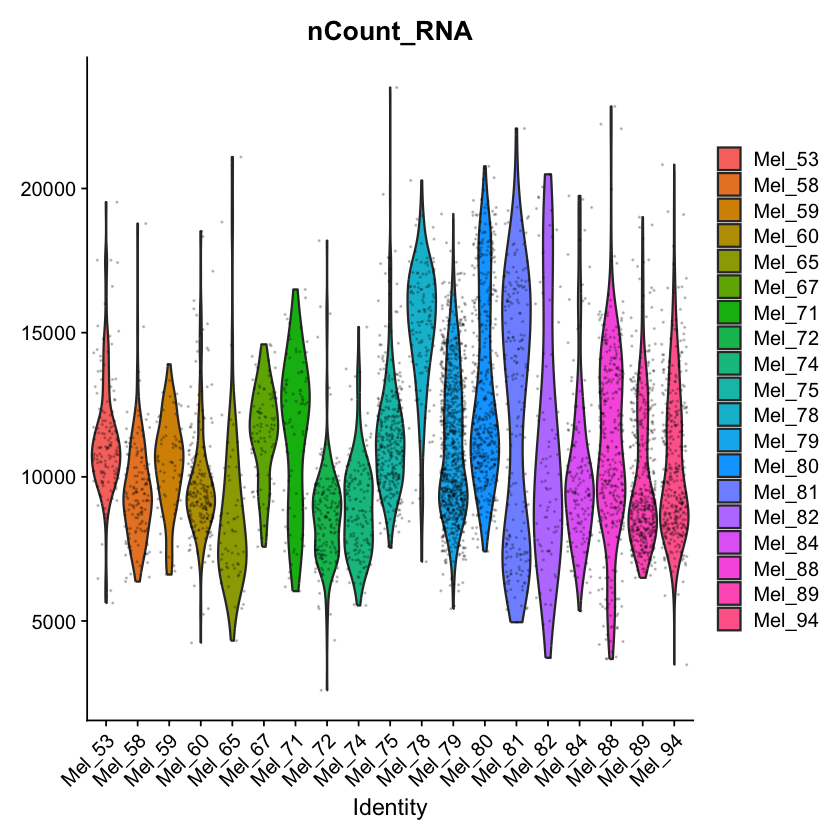

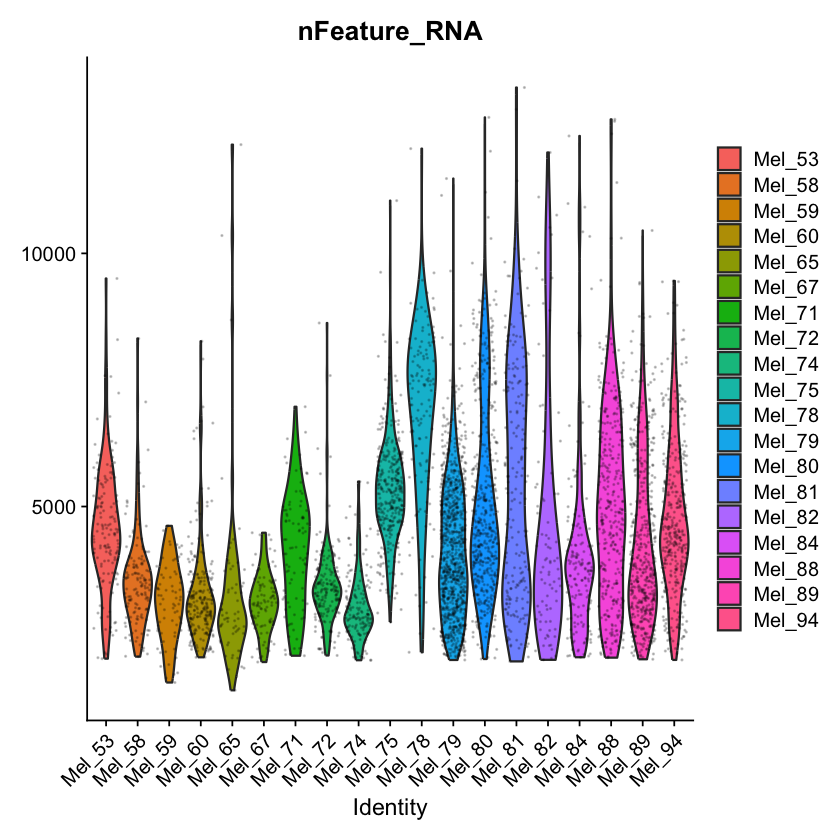

In [36]:
# set colors
#cnames<-setNames(rep(c("cyan3","darkgoldenrod1"),each=4),levels(factor(metadata$tumor_cells))) 

# plot
VlnPlot(adp, features = "nCount_RNA", layer="counts", group.by="tumor_cells",raster=FALSE,alpha=0.2) #+
  #scale_fill_manual(values=cnames)

 
VlnPlot(adp, features = "nFeature_RNA", layer="counts", group.by="tumor_cells",raster=FALSE,alpha=0.2) #+


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”


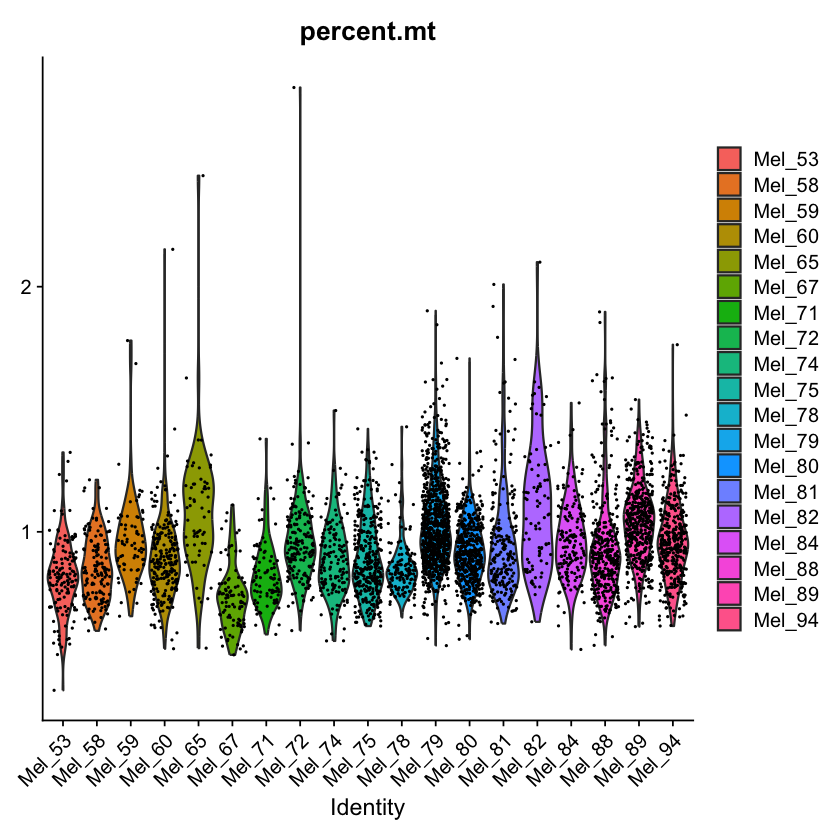

In [71]:
VlnPlot(adp, features = "percent.mt", group.by="tumor_cells") +
  #scale_fill_manual(values=cnames) +
  geom_hline(yintercept=10,color="red")

In [ ]:
FeatureScatter(adp, feature1 = "percent.mt", feature2 ="nFeature_RNA" , group.by="tumor_cells",split.by="cell_type") #+


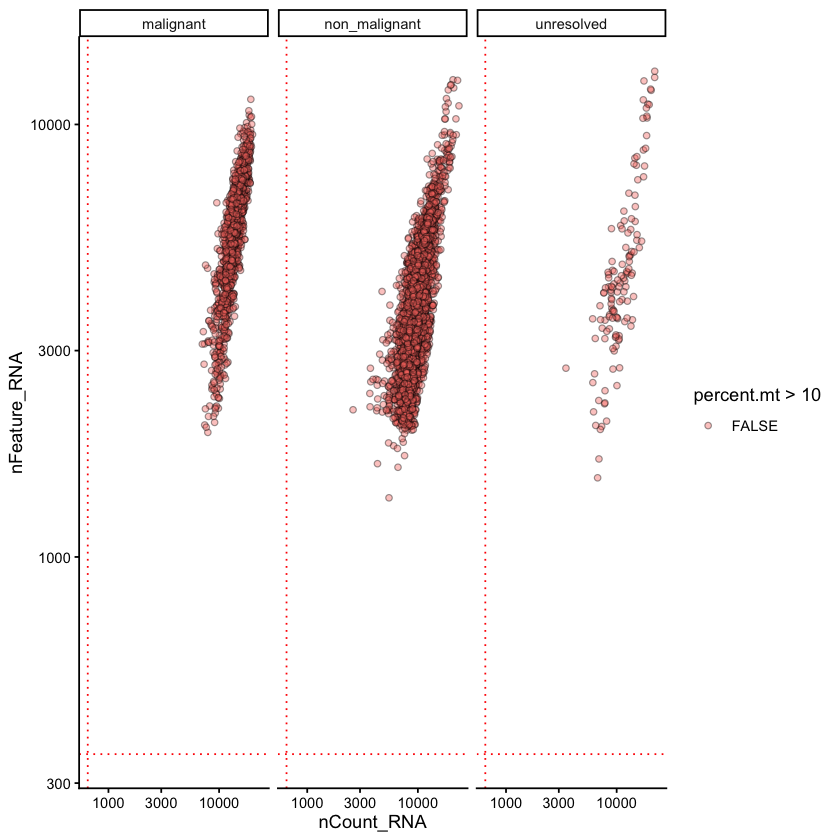

In [75]:
ggplot(metadata) +
  geom_point(aes(x=nCount_RNA,y=nFeature_RNA,fill=percent.mt > 10),shape=21,alpha=0.4) + 
  theme_classic() +
  scale_x_log10()+
  scale_y_log10()+
  facet_grid(.~malignant) +
  geom_vline(xintercept = 650,color="red",linetype="dotted")+
  geom_hline(yintercept=350,color="red", linetype="dotted")

In [76]:
adp <- subset(adp, subset = nFeature_RNA >= 200)

In [80]:
counts <- GetAssayData(adp, layer = "counts")

keep_genes <- rowSums(counts > 0) >= 3

adp <- subset(adp, features = rownames(counts)[keep_genes])

In [81]:
glimpse(adp)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ meta.data   :'data.frame':	4645 obs. of  7 variables:
  .. ..$ orig.ident  : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA  : num [1:4645] 7143 8916 12578 16764 16327 ...
  .. ..$ nFeature_RNA: int [1:4645] 3365 3637 4660 6387 5913 8366 2826 2563 4721 6021 ...
  .. ..$ tumor_cells : Factor w/ 19 levels "Mel_53","Mel_58",..: 8 2 7 14 13 14 8 9 7 13 ...
  .. ..$ malignant   : Factor w/ 3 levels "malignant","non_malignant",..: 2 2 1 1 1 1 2 2 1 1 ...
  .. ..$ cell_type   : Factor w/ 7 levels "B_cell","CAF",..: 1 6 7 7 7 7 6 6 7 7 ...
  .. ..$ percent.mt  : num [1:4645] 0.896 0.787 0.62 0.813 0.793 ...
  ..@ active.assay: chr "RNA"
  ..@ active.ident: Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..- attr(*, "names")= chr [1:4645] "Cy72_CD45_H02_S758_comb" "CY58_1_CD45_B02_

In [82]:
# use multicore parallelism (Linux/SageMaker)
plan("multicore", workers = 22)

# increase memory limit for futures
options(future.globals.maxSize = 200 * 1024^3)  # 12 GB

In [84]:
adp <- SCTransform(adp, vars.to.regress = "percent.mt", verbose = FALSE)

In [85]:
adp <- RunPCA(adp, verbose = FALSE,assay="SCT")

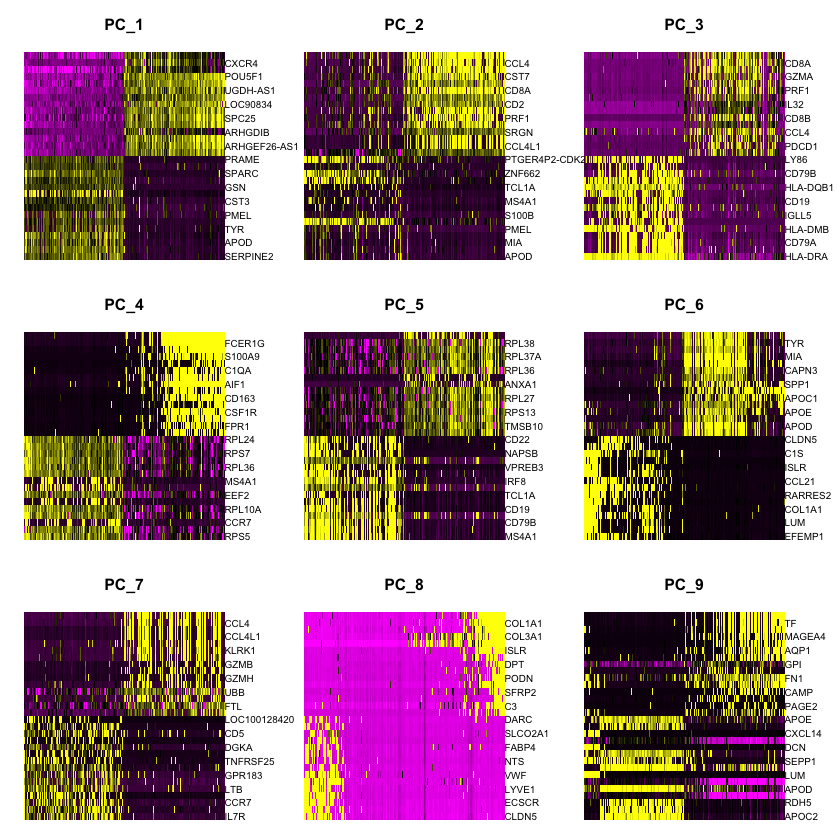

In [86]:
DimHeatmap(adp, dims = 1:9, cells = 500, balanced = TRUE,ncol=3)

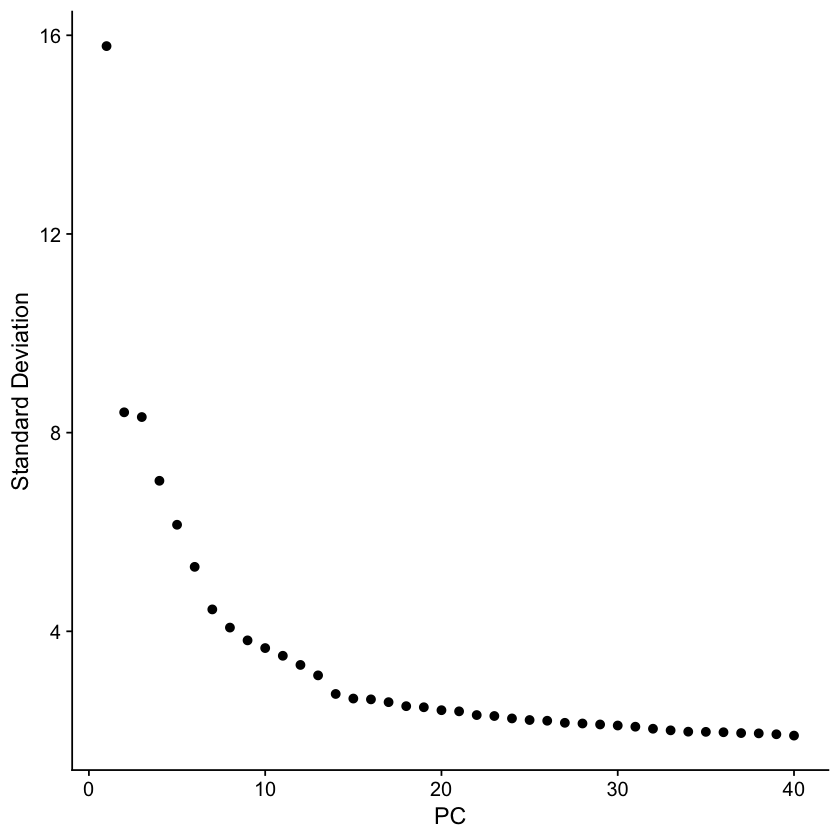

In [87]:
ElbowPlot(adp, ndims = 40)

In [88]:
adp <- FindNeighbors(adp, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



In [89]:
adp <- FindClusters(adp, resolution = 0.1)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4645
Number of edges: 155558

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9676
Number of communities: 12
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (eeab83584ad6cd261fae51957591a363-119); on eeab83584ad6cd261fae51957591a363@Admins-MacBook-Air-4.local<16020>]”


In [90]:
adp <- RunUMAP(adp,dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
16:46:16 UMAP embedding parameters a = 0.9922 b = 1.112

16:46:16 Read 4645 rows and found 30 numeric columns

16:46:16 Using Annoy for neighbor search, n_neighbors = 30

16:46:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:46:16 Writing NN index file to temp file /var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T//RtmpgUgwJg/file3e94d408fcb

16:46:16 Searching Annoy index using 22 threads, search_k = 3000

16:46:16 Annoy recall = 100%

16:46:17 Commencing smooth kNN distance calibra

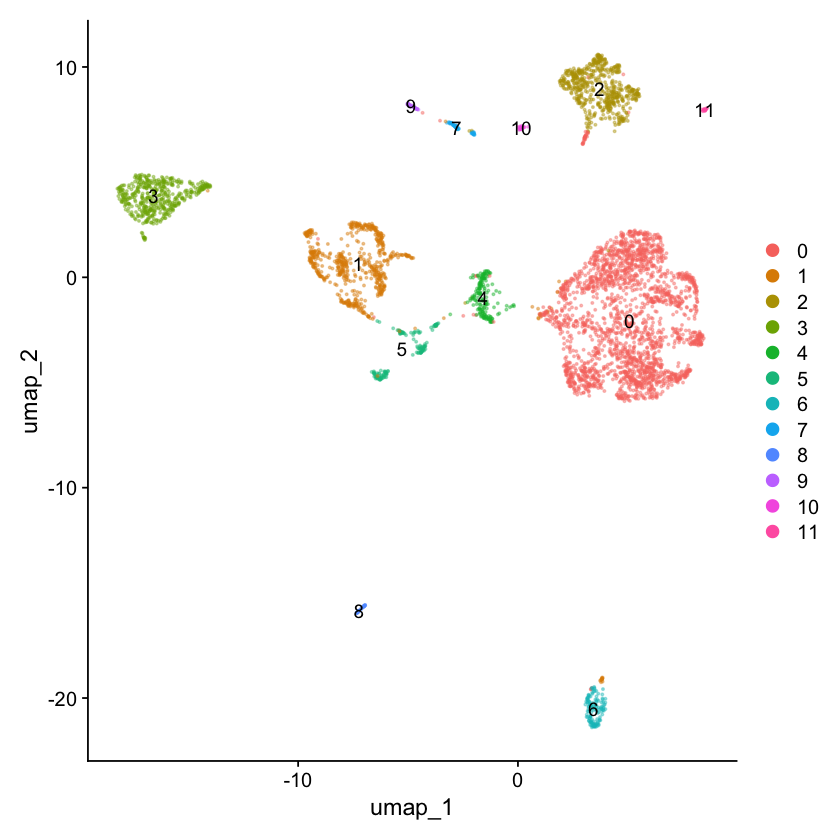

In [125]:
DimPlot(adp, reduction = "umap", label = TRUE,#group.by = c("cell_type", "malignant", "seurat_clusters"),
        alpha=0.4, ncol=1)

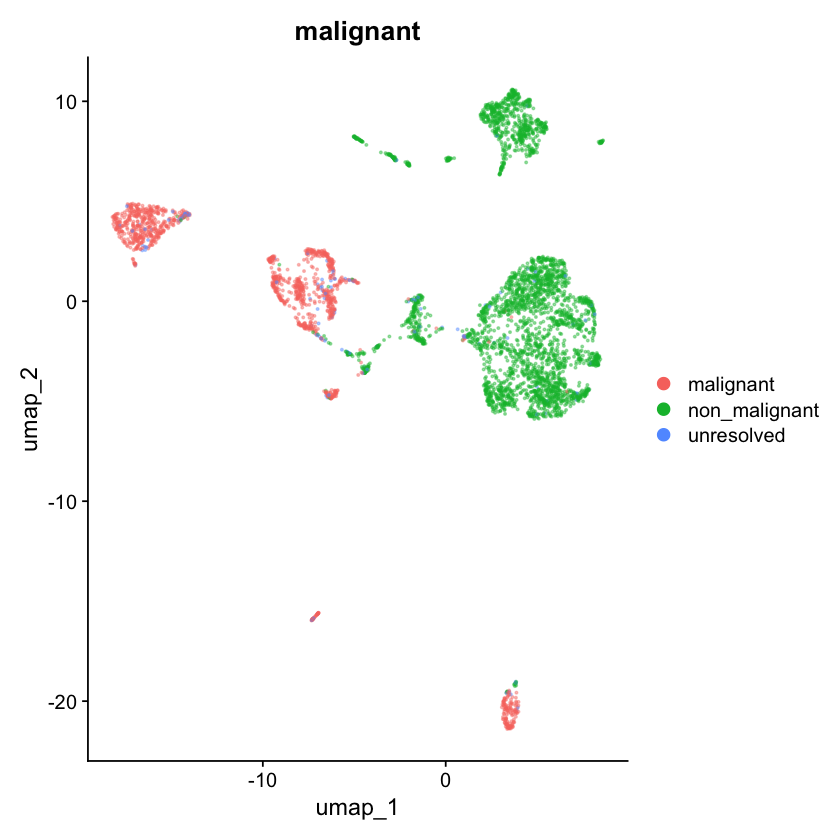

In [101]:
DimPlot(adp, reduction = "umap", group.by = c("malignant"),
        alpha=0.4, ncol=1)

In [102]:
adp<-PrepSCTFindMarkers(adp,verbose=T)

Only one SCT model is stored - skipping recalculating corrected counts



In [103]:
# find all markers
adp_filt_markers <- FindAllMarkers(adp, only.pos = TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11



In [104]:
#ordering the results
adp_filt_markers <- adp_filt_markers %>% 
  arrange(cluster,desc(avg_log2FC), desc(p_val_adj))

#examine a small subset
adp_filt_markers %>%
    group_by(cluster) %>%
    slice_max(n = 5, order_by = avg_log2FC)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
4.802109e-12,7.095662,0.020,0.000,1.052766e-07,0,LINC00593
1.475072e-08,6.923023,0.014,0.000,3.233800e-04,0,RAB19
7.103894e-29,6.387843,0.057,0.002,1.557387e-24,0,NCR1
1.643721e-17,5.830456,0.033,0.001,3.603529e-13,0,UTS2
2.222318e-87,5.804777,0.171,0.007,4.871987e-83,0,JAKMIP1
9.758579e-119,7.623339,0.137,0.001,2.139373e-114,1,SLC38A8
4.200853e-36,7.053725,0.041,0.000,9.209530e-32,1,LINC00112
6.771542e-17,6.983335,0.017,0.000,1.484525e-12,1,COL20A1
5.851203e-55,6.120839,0.071,0.001,1.282759e-50,1,PASD1


Warning message in DoHeatmap(adp, features = top20$gene):
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: CDHR5, IFNE, EPHB1, INSM1, KCNN1, FAM187B, ADIG, SHD, PLEKHD1, KRT5, GUCY2D, LAMP5, LOC149086, NCR2, CUX2, COL26A1, SLC32A1, LRRC26, SCT, SLN, JSRP1, LINC00675, DEFB4B, AMN, ZNRF4, TMEM239, FGF16, CNKSR1, TRIM31, C5orf48, SDC1, DPEP1, PRKCG, CCDC162P, IGF2-AS, AMPD1, CCL23, MYRIP, SOX17, PREX2, HSPA12B, CYYR1, SELE, GPIHBP1, ARHGEF15, GABRD, CAPN11, LCN6, SEMA3F, FCN3, ALDH1L1, ASIC2, SPRR2D, GAGE4, GAGE2C, REG3G, VCX3B, PAGE1, COL9A1, GAGE5, LUZP4, IGFBP1, GAL3ST1, ST8SIA5, FABP6, VCX3A, KRT12, MAG, KIF26A, ALDH3A1, GDF3, LOC100506388, EXOC3L1, LINC00636, P2RX2, FXYD6-FXYD2, FAM162B, ERICH1-AS1, NOVA2, CACNA1A, GPR182, STAB2, MUC5B, LRTM2, TERT, ACADL, FABP1, LCN15, AGR2, HAPLN1, MYCN, SAA2-SAA4, MYCNOS, LOC100133123, DEFB123, BPIFA2, PPP1R1B, BPIFB1, LINC00313, NGEF, MS4A8B, TCEAL7, ANKRD2, COL14A1, CPZ, CNN1, INS-IGF2, PRRX2

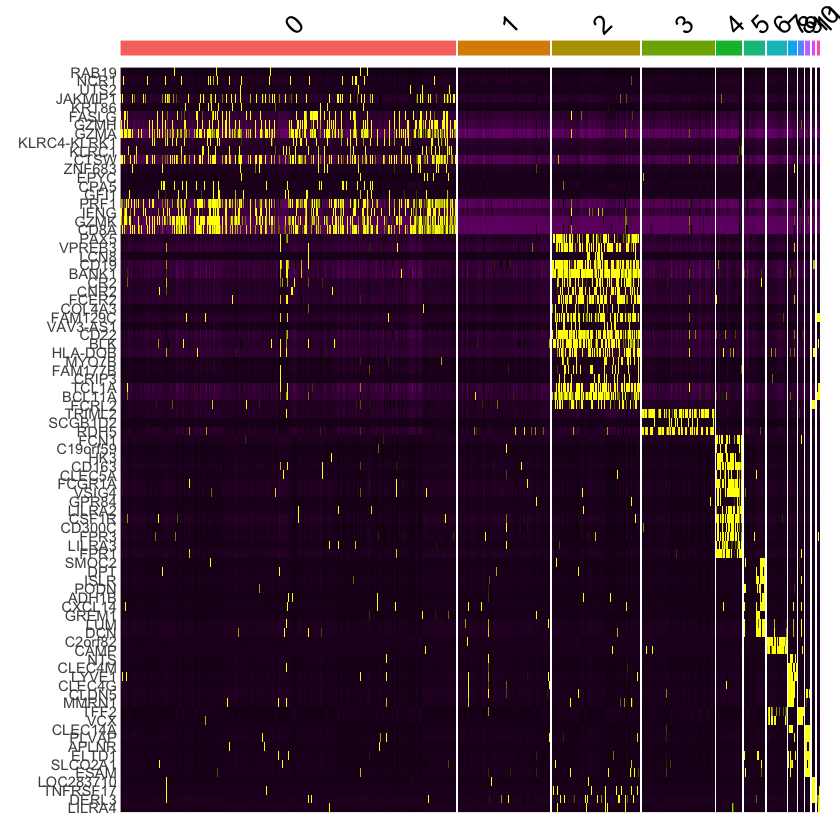

In [106]:
top20<-adp_filt_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 20) %>%
    ungroup() 
DoHeatmap(adp, features = top20$gene) + NoLegend()

In [107]:
# load gene set preparation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
# load cell type annotation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")

In [109]:
seurat_package_v5 <- isFALSE('counts' %in% names(attributes(adp[["RNA"]])));
print(sprintf("Seurat object %s is used", ifelse(seurat_package_v5, "v5", "v4")))

[1] "Seurat object v5 is used"


In [110]:
scRNAseqData_scaled <- if (seurat_package_v5) as.matrix(adp[["SCT"]]$scale.data) else as.matrix(adp[["SCT"]]@scale.data)

In [111]:
adp

An object of class Seurat 
44212 features across 4645 samples within 2 assays 
Active assay: SCT (21923 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [119]:
# DB file
db_ <- "https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx";
tissue <- "Immune system" # e.g. Immune system,Pancreas,Liver,Eye,Kidney,Brain,Lung,Adrenal,Heart,Intestine,Muscle,Placenta,Spleen,Stomach,Thymus 

# prepare gene sets
gs_list <- gene_sets_prepare(db_, tissue)

Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in

In [120]:
es.max <- sctype_score(scRNAseqData = scRNAseqData_scaled, scaled = TRUE, gs = gs_list$gs_positive, gs2 = gs_list$gs_negative)

In [121]:
cL_resutls <- do.call("rbind", lapply(unique(adp@meta.data$seurat_clusters), function(cl){
    es.max.cl = sort(rowSums(es.max[ ,rownames(adp@meta.data[adp@meta.data$seurat_clusters==cl, ])]), decreasing = !0)
    head(data.frame(cluster = cl, type = names(es.max.cl), scores = es.max.cl, ncells = sum(adp@meta.data$seurat_clusters==cl)), 10)
}))

In [122]:
sctype_scores <- cL_resutls %>% group_by(cluster) %>% top_n(n = 1, wt = scores)  

In [123]:
sctype_scores$type[as.numeric(as.character(sctype_scores$scores)) < sctype_scores$ncells/4] <- "Unknown"
print(sctype_scores[,1:3])

# A tibble: 12 × 3
# Groups:   cluster [12]
   cluster type                         scores
   <fct>   <chr>                         <dbl>
 1 2       Naive B cells                3184. 
 2 0       CD8+ NKT-like cells          4265. 
 3 1       Basophils                     192. 
 4 6       Neutrophils                   218. 
 5 4       Macrophages                  1445. 
 6 5       HSC/MPP cells                 146. 
 7 11      Plasmacytoid Dendritic cells   84.7
 8 7       Endothelial                   243. 
 9 9       Endothelial                   314. 
10 3       Basophils                     657. 
11 8       Basophils                      62.9
12 10      Plasma B cells                184. 


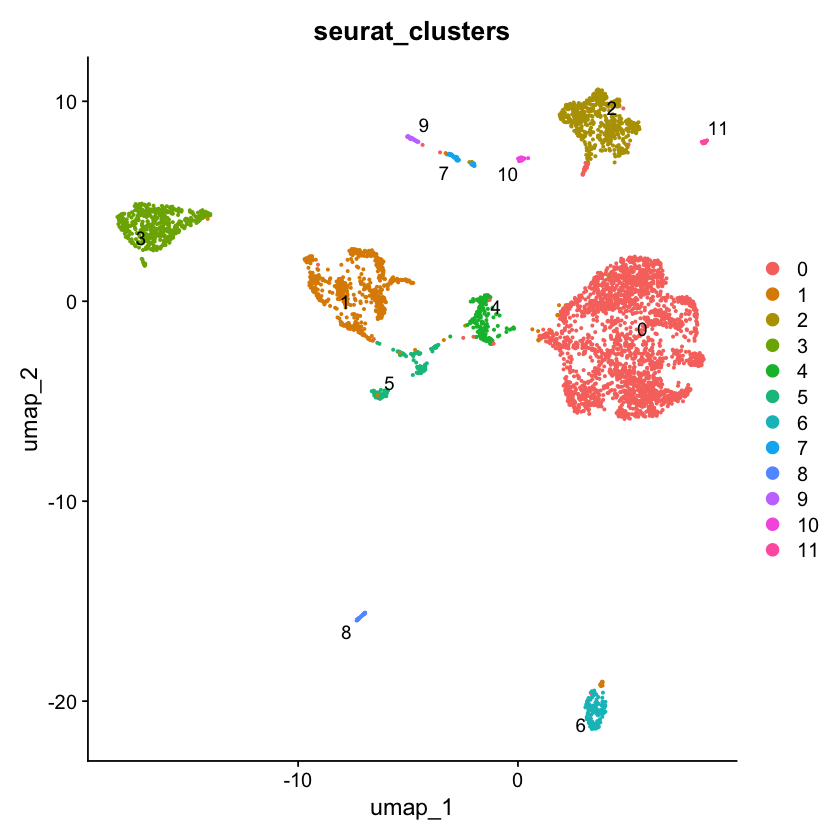

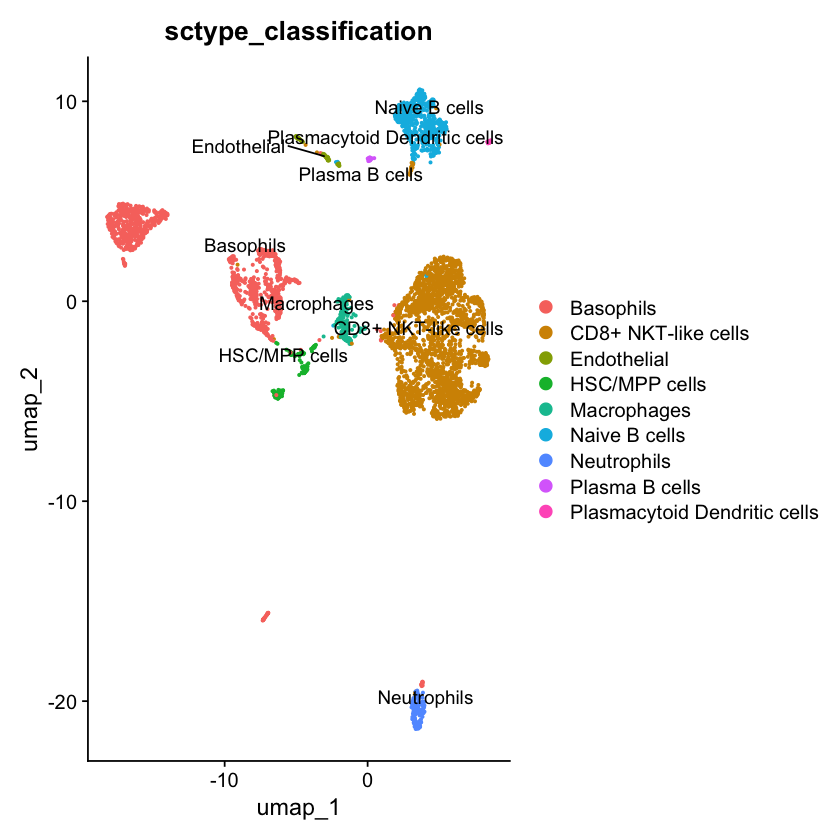

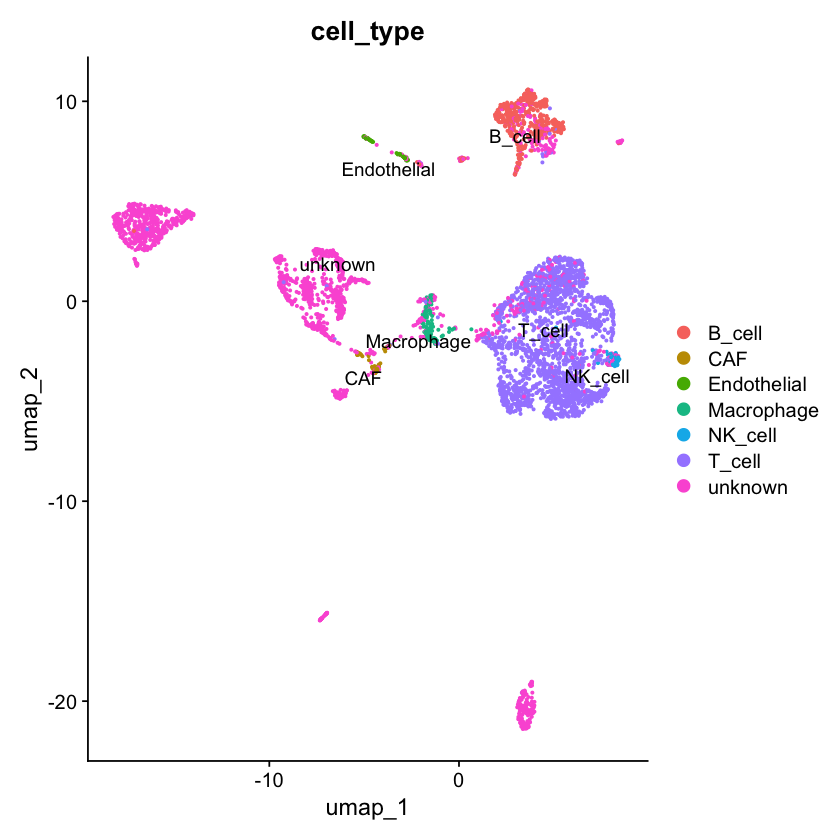

In [132]:
adp@meta.data$sctype_classification = ""
for(j in unique(sctype_scores$cluster)){
  cl_type = sctype_scores[sctype_scores$cluster==j,]; 
  adp@meta.data$sctype_classification[adp@meta.data$seurat_clusters == j] = as.character(cl_type$type[1])
}

DimPlot(adp, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('seurat_clusters'), ncol=1) 
DimPlot(adp, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('sctype_classification'), ncol=1) 
DimPlot(adp, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('cell_type'), ncol=1) 

In [133]:
adp_malignant <- subset(adp, subset = malignant == "malignant")

adp_non_malignant <- subset(adp, subset = malignant == "non_malignant")

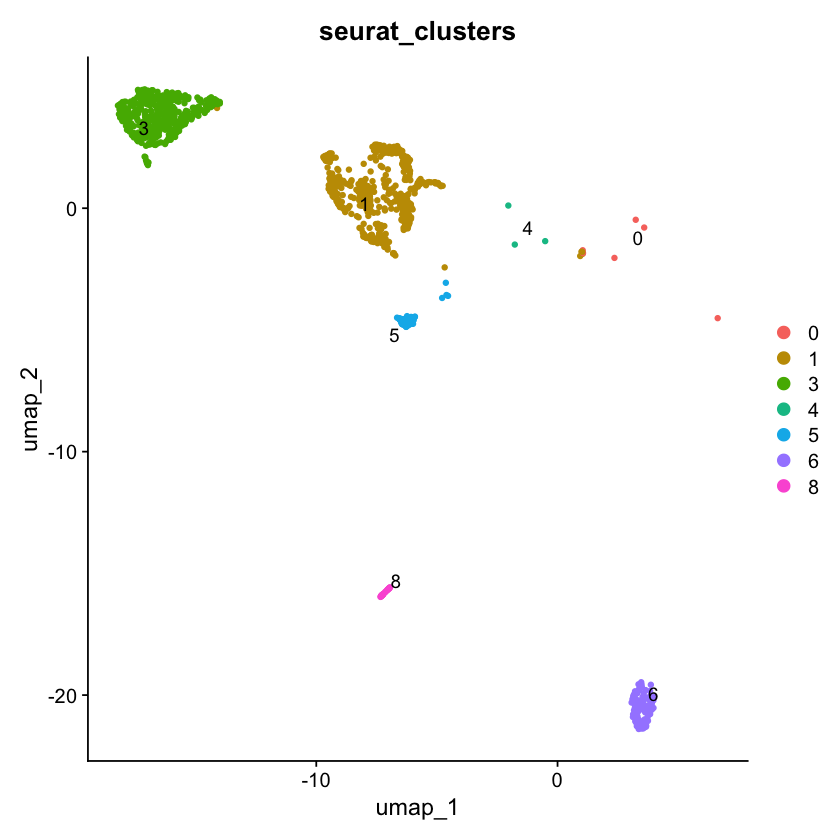

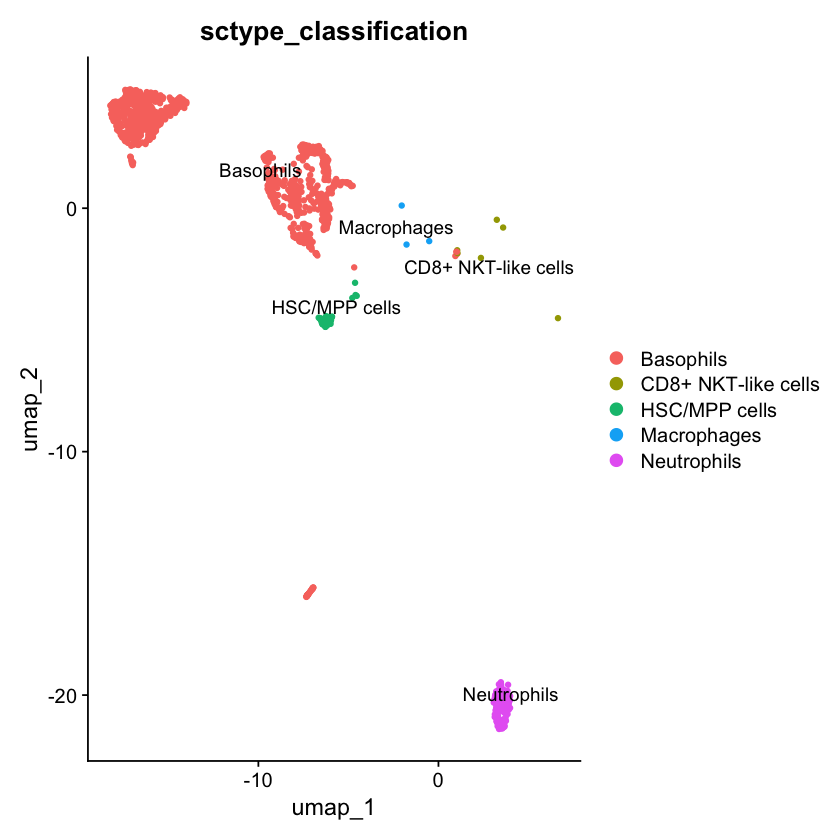

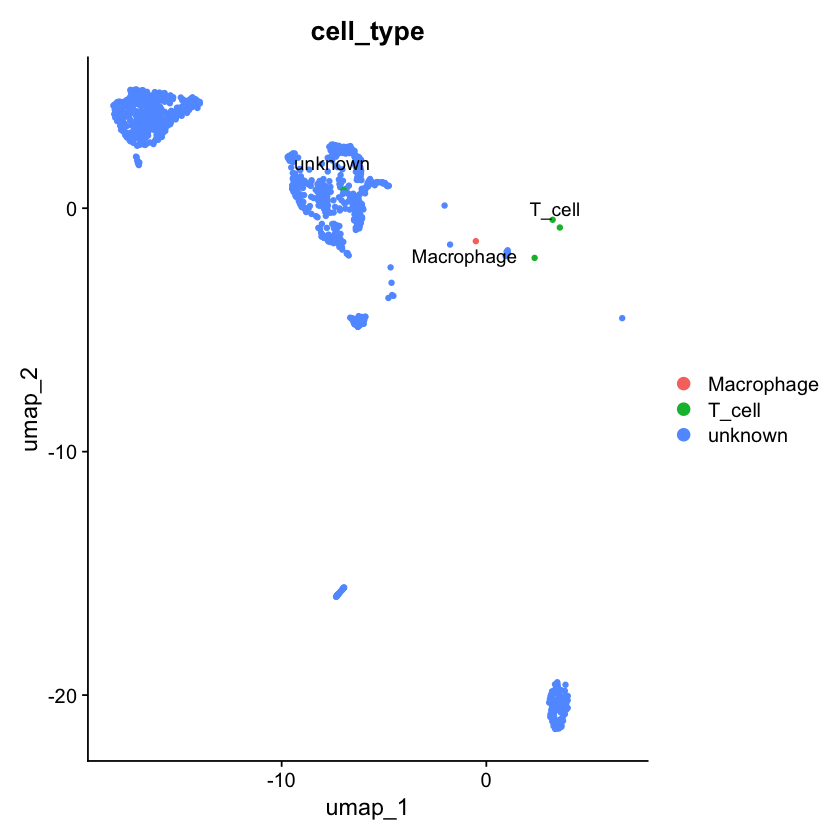

In [134]:
DimPlot(adp_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('seurat_clusters'), ncol=1) 
DimPlot(adp_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('sctype_classification'), ncol=1) 
DimPlot(adp_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('cell_type'), ncol=1) 

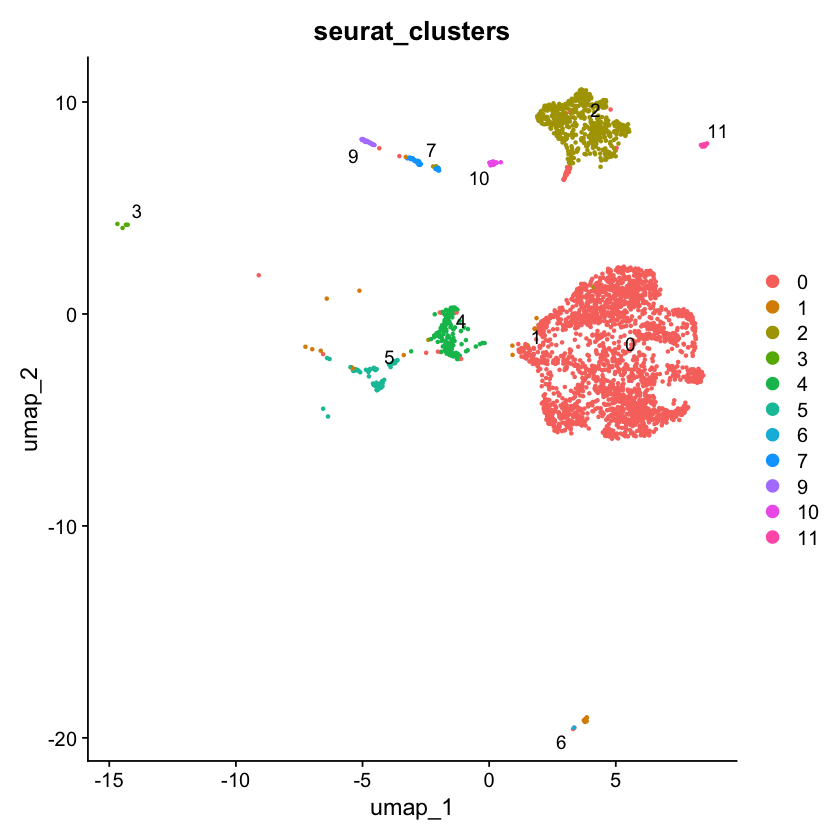

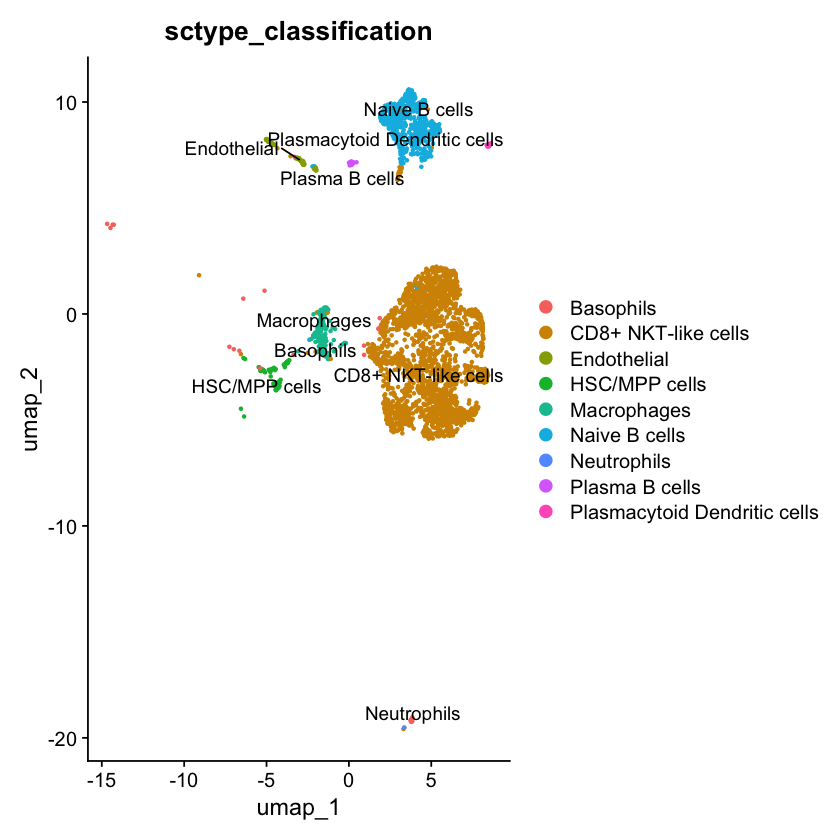

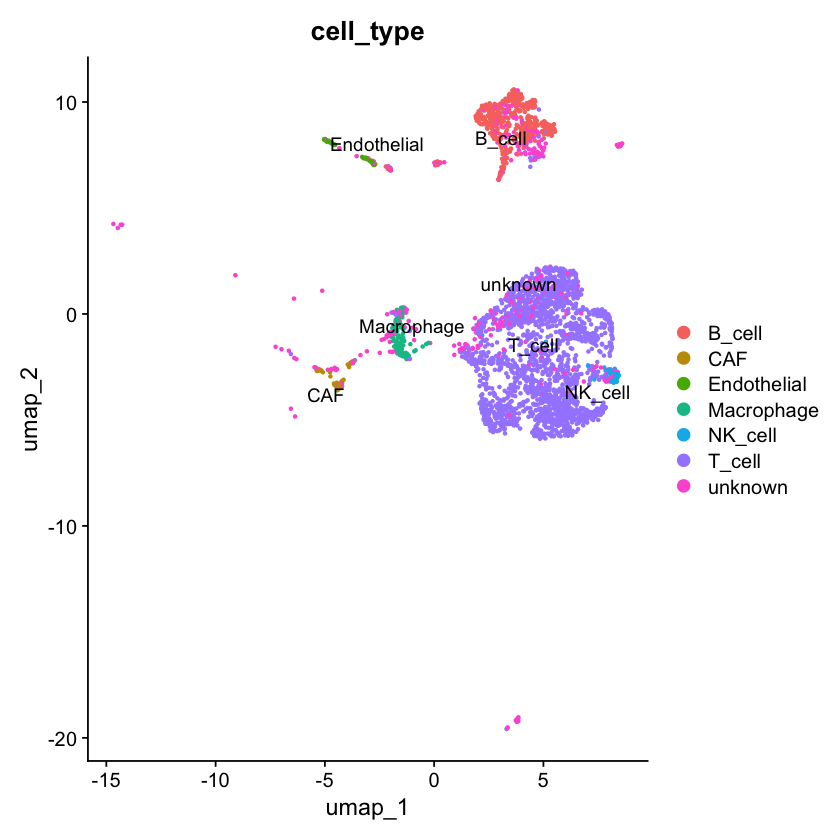

In [135]:
DimPlot(adp_non_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('seurat_clusters'), ncol=1) 
DimPlot(adp_non_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('sctype_classification'), ncol=1) 
DimPlot(adp_non_malignant, reduction = "umap", label = TRUE, repel = TRUE, group.by = c('cell_type'), ncol=1) 

In [136]:
counts <- GetAssayData(adp, layer = "counts")

In [137]:
write.table(
  as.matrix(counts),
  file = "counts_matrix.tsv",
  sep = "\t",
  quote = FALSE,
  col.names = NA
)

In [138]:
write.table(
  metadata,
  file = "metadata.tsv",
  sep = "\t",
  quote = FALSE
)